# Final Analysis: OCR Error Rate Assessment for HathiTrust Re-OCR Project

This notebook evaluates whether re-OCR of HathiTrust volumes improved text quality by comparing:
- **gsent**: ground truth sentences (Gutenberg / Google Books)
- **hsent**: original HathiTrust OCR text
- **matched_honed_lev**: sentence-aligned re-OCR text (from aligner script)

**Data source:** `found_in_january_run_improved_ALL.csv` — the complete dataset of 167,079 high/low sentence pairs, with aligner matches for all but 2,264 sentences.

**Metrics computed:**
1. CER / WER (with and without stopwords)
2. BLEU score
3. OCRoscope-style 7-gram analysis

In [5]:
%pip install nltk sacrebleu --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from pathlib import Path
import re
import unicodedata
import warnings
from collections import Counter

import Levenshtein
from jiwer import wer as jiwer_wer
import nltk
from nltk.corpus import stopwords
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import sacrebleu

nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

In [7]:
# ---------------------------------------------------------------------------
# Helper functions (ported from wer_cer.py and existing notebooks)
# ---------------------------------------------------------------------------

def safe_div(num, den):
    """Avoid division by zero."""
    return float('nan') if den == 0 else num / den


def normalize_light(s: str) -> str:
    """Strip hyphens and COLLAPSE whitespace (for character-level CER).

    Previously this stripped *all* whitespace (re.sub(r'\\s+', '', ...)), which
    made CER insensitive to word-boundary differences between hsent (NLP-style
    tokenized punctuation) and matched_honed_lev (raw prose). Fixed to collapse.
    """
    if not isinstance(s, str):
        s = '' if s is None else str(s)
    s = s.replace('\n', ' ').replace('\r', ' ')
    s = s.replace('--', '')
    s = s.replace('-', '')
    s = re.sub(r'\s+', ' ', s).strip()
    return s


def normalize_text(text: str) -> str:
    """NFKC + light cleanup + lowercase (for normalized CER)."""
    if not isinstance(text, str):
        text = '' if text is None else str(text)
    text = unicodedata.normalize('NFKC', text)
    text = normalize_light(text)
    text = text.lower()
    return text.strip()


def normalize_for_wer(s: str) -> str:
    """Light normalization that preserves word boundaries (for WER)."""
    if not isinstance(s, str):
        s = '' if s is None else str(s)
    s = s.replace('\n', ' ').replace('\r', ' ')
    s = s.replace('--', ' ').replace('-', '')
    s = re.sub(r'\s+', ' ', s).strip()
    return s


_PUNCT_RE = re.compile(r'[^\w\s]', re.UNICODE)

def normalize_heavy(s: str) -> str:
    """Content-focused normalization: NFKC + lowercase + strip punctuation.

    This is the PRIMARY metric. hsent has NLP-style tokenized punctuation
    ("Well , " said) while matched_honed_lev has raw prose punctuation
    ("Well," said). Stripping punctuation makes comparison content-only.
    """
    if not isinstance(s, str):
        s = '' if s is None else str(s)
    s = unicodedata.normalize('NFKC', s)
    s = s.replace('\n', ' ').replace('\r', ' ').replace('--', '').replace('-', '')
    s = s.lower()
    s = _PUNCT_RE.sub(' ', s)
    return re.sub(r'\s+', ' ', s).strip()


TOL = 0.01  # tolerance for float noise

def improvement_stats(delta_series, tol=TOL):
    """Compute improvement/worsening counts for a delta series."""
    s = delta_series.dropna()
    improved = (s < -tol).sum()
    worse    = (s >  tol).sum()
    same     = ((s >= -tol) & (s <= tol)).sum()
    total    = len(s)
    return {
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(ddof=1),
        'improved': int(improved),
        'worse': int(worse),
        'same': int(same),
        'pct_improved': 100 * improved / total if total else np.nan,
        'pct_worse':    100 * worse    / total if total else np.nan,
        'pct_same':     100 * same     / total if total else np.nan,
        'total': int(total),
    }


def compute_book_improvement_stats(df, delta_col, group_col='hid', tol=TOL):
    """Per-book aggregation of improvement deltas."""
    return (
        df.groupby(group_col)
          .agg(
              mean_delta   = (delta_col, 'mean'),
              median_delta = (delta_col, 'median'),
              improved     = (delta_col, lambda s: (s < -tol).sum()),
              worse        = (delta_col, lambda s: (s >  tol).sum()),
              same         = (delta_col, lambda s: ((s >= -tol) & (s <= tol)).sum()),
              total        = (delta_col, 'count'),
          )
          .reset_index()
    )


def fast_cer(ref: str, hyp: str) -> float:
    """CER on normalize_light strings (whitespace collapsed, hyphens stripped)."""
    r = normalize_light(str(ref))
    h = normalize_light(str(hyp))
    return safe_div(Levenshtein.distance(r, h), len(r))


def fast_cer_norm(ref: str, hyp: str) -> float:
    """CER on normalize_text strings (NFKC + lowercase)."""
    r = normalize_text(str(ref))
    h = normalize_text(str(hyp))
    return safe_div(Levenshtein.distance(r, h), len(r))


def fast_cer_heavy(ref: str, hyp: str) -> float:
    """CER on normalize_heavy strings (content-focused: NFKC + lower + no punct)."""
    r = normalize_heavy(str(ref))
    h = normalize_heavy(str(hyp))
    return safe_div(Levenshtein.distance(r, h), len(r))


def fast_wer(ref: str, hyp: str) -> float:
    """WER preserving word boundaries."""
    r = normalize_for_wer(str(ref))
    h = normalize_for_wer(str(hyp))
    if not r.strip():
        return float('nan')
    return jiwer_wer(r, h)


def fast_wer_heavy(ref: str, hyp: str) -> float:
    """WER on normalize_heavy strings (content-focused)."""
    r = normalize_heavy(str(ref))
    h = normalize_heavy(str(hyp))
    if not r.strip():
        return float('nan')
    return jiwer_wer(r, h)


print('Helpers loaded.')

Helpers loaded.


---
## 1. Data Loading & Completeness Check

In [8]:
# Paths
HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "error_rate" else HERE
DATA_DIR = PROJECT_ROOT / "data"
CACHE_DIR = PROJECT_ROOT / "error_rate" / "_cache"
CACHE_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "found_in_january_run_improved_ALL.csv"
REVIEW_DIR = DATA_DIR / "reocr_review"  # used by Figure 6 in the publication-figures notebook

TOL = 0.01

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Loading: {DATA_PATH.name}")

df_raw = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

PROJECT_ROOT: /Users/danielevans/Documents/uiuc/research/reocr-project
Loading: found_in_january_run_improved_ALL.csv
Raw shape: (167079, 21)
Columns: ['idx', 'csv_source', 'domain', 'gid', 'hid', 'pubdate', 'cidx', 'sidx', 'cer', 'wer', 'gsent', 'hsent', 'hsent_norm', 'matched_sentence', 'matched_sent_idx', 'score_containment', 'score_bigram', 'score_lev', 'score_combined', 'matched_honed_lev', 'matched_honed_lev_score']


In [9]:
display(df_raw.head(3))
print(f'\nDtypes:\n{df_raw.dtypes}')
print(f'\nDomain distribution:')
display(df_raw['domain'].value_counts())
print(f'\ncsv_source distribution:')
display(df_raw['csv_source'].value_counts())
print(f'Publication date range: {df_raw["pubdate"].min()} - {df_raw["pubdate"].max()}')
print(f'Unique hid (volumes): {df_raw["hid"].nunique()}')
print(f'Unique gid (ground truth sources): {df_raw["gid"].nunique()}')

,idx,csv_source,domain,gid,hid,pubdate,cidx,sidx,cer,wer,...,hsent,hsent_norm,matched_sentence,matched_sent_idx,score_containment,score_bigram,score_lev,score_combined,matched_honed_lev,matched_honed_lev_score
0,0,highpairs,Fiction,56600,uc2.ark+=13960=t7dr2vk0r,1870,0,2,0.09375,0.200000,...,""" Scarcely so much , mamma ; indeed it wants a...",scarcely so much mamma indeed it wants a quart...,""" Scarcely so much, mamma ; indeed it wants a ...",154.0,1.0,1.0,1.0,100.0,""" Scarcely so much, mamma ; indeed it wants a ...",0.953846
1,1,highpairs,Fiction,56600,uc2.ark+=13960=t7dr2vk0r,1870,0,3,0.08000,0.285714,...,the coach does not an ive till half past eig...,the coach does not an ive till half past eight...,""" Scarcely so much, mamma ; indeed it wants a ...",154.0,1.0,1.0,1.0,100.0,the coach does not an-ive till half-past eight...,0.902913
2,2,highpairs,Fiction,56600,uc2.ark+=13960=t7dr2vk0r,1870,0,5,0.03200,0.120000,...,"this waiting , it destroys me ; "" rejoined the...",this waiting it destroys me rejoined the first...,"this waiting, it destroys me ;"" rejoined the f...",156.0,1.0,1.0,1.0,100.0,"this waiting, it destroys me ;"" rejoined the f...",0.960630



Dtypes:
idx                          int64
csv_source                  object
domain                      object
gid                          int64
hid                         object
pubdate                      int64
cidx                         int64
sidx                         int64
cer                        float64
wer                        float64
gsent                       object
hsent                       object
hsent_norm                  object
matched_sentence            object
matched_sent_idx           float64
score_containment          float64
score_bigram               float64
score_lev                  float64
score_combined             float64
matched_honed_lev           object
matched_honed_lev_score    float64
dtype: object

Domain distribution:


domain
Fiction              157417
Social_Science         4380
Agriculture            3204
World_War_History      2078
Name: count, dtype: int64


csv_source distribution:


csv_source
highpairs    104893
lowpairs      62186
Name: count, dtype: int64

Publication date range: 1793 - 1984
Unique hid (volumes): 346
Unique gid (ground truth sources): 189


In [10]:
# Filter out rows with blank matched_honed_lev
blank_mask = (
    df_raw['matched_honed_lev'].isna() |
    (df_raw['matched_honed_lev'].astype(str).str.strip() == '') |
    (df_raw['matched_honed_lev'].astype(str).str.strip() == 'nan')
)
n_blank = blank_mask.sum()
print(f'Rows with blank matched_honed_lev: {n_blank}')
print(f'Rows with valid matched_honed_lev: {(~blank_mask).sum()}')

df = df_raw[~blank_mask].copy()
print(f'\nWorking dataset: {len(df):,} rows')

Rows with blank matched_honed_lev: 2264
Rows with valid matched_honed_lev: 164815

Working dataset: 164,815 rows


In [11]:
# Verify text columns are populated
for col in ['gsent', 'hsent', 'matched_honed_lev']:
    n_empty = df[col].isna().sum()
    n_blank_str = (df[col].astype(str).str.strip() == '').sum()
    print(f'{col}: {n_empty} NaN, {n_blank_str} blank strings')

# Check for the excluded HTID mentioned by colleague
excluded_htid_pattern = 'uc2.ark'
htids_with_uc2 = df['hid'].str.contains('uc2.ark.*13960.*t1mg7g37n', regex=True, na=False)
print(f'\nRows from excluded HTID (uc2.ark:/13960/t1mg7g37n): {htids_with_uc2.sum()}')

gsent: 0 NaN, 0 blank strings
hsent: 0 NaN, 0 blank strings
matched_honed_lev: 0 NaN, 0 blank strings

Rows from excluded HTID (uc2.ark:/13960/t1mg7g37n): 0


---
## 2. CER / WER Analysis

In [12]:
%%time
# Compute CER and WER: before (gsent vs hsent) and after (gsent vs matched_honed_lev)

# CER (character-level, whitespace stripped)
df['cer_before'] = df.apply(lambda r: fast_cer(r['gsent'], r['hsent']), axis=1)
df['cer_after']  = df.apply(lambda r: fast_cer(r['gsent'], r['matched_honed_lev']), axis=1)

# CER normalized (NFKC + lowercase)
df['cer_before_norm'] = df.apply(lambda r: fast_cer_norm(r['gsent'], r['hsent']), axis=1)
df['cer_after_norm']  = df.apply(lambda r: fast_cer_norm(r['gsent'], r['matched_honed_lev']), axis=1)

# WER (word-level, preserving word boundaries)
df['wer_before'] = df.apply(lambda r: fast_wer(r['gsent'], r['hsent']), axis=1)
df['wer_after']  = df.apply(lambda r: fast_wer(r['gsent'], r['matched_honed_lev']), axis=1)

print('CER/WER computation complete.')

CER/WER computation complete.
CPU times: user 20.9 s, sys: 913 ms, total: 21.8 s
Wall time: 23.5 s


In [13]:
%%time
# Primary metrics: content-focused normalization (NFKC + lowercase + strip punctuation).
# This is what we report as the main result. The lighter metrics above become
# sensitivity analyses.
#
# Motivation: hsent uses NLP-style tokenized punctuation (' " Well , " said '),
# while matched_honed_lev is raw prose from the source .txt files
# (' "Well," said '). Without stripping punctuation, the CER/WER delta is
# dominated by punctuation-spacing style, not content quality.

df['cer_before_heavy'] = df.apply(lambda r: fast_cer_heavy(r['gsent'], r['hsent']), axis=1)
df['cer_after_heavy']  = df.apply(lambda r: fast_cer_heavy(r['gsent'], r['matched_honed_lev']), axis=1)
df['cer_delta_heavy']  = df['cer_after_heavy'] - df['cer_before_heavy']

df['wer_before_heavy'] = df.apply(lambda r: fast_wer_heavy(r['gsent'], r['hsent']), axis=1)
df['wer_after_heavy']  = df.apply(lambda r: fast_wer_heavy(r['gsent'], r['matched_honed_lev']), axis=1)
df['wer_delta_heavy']  = df['wer_after_heavy'] - df['wer_before_heavy']

print('Heavy-normalization CER/WER complete.')
print('\n=== CER (heavy norm) ===')
for k, v in improvement_stats(df['cer_delta_heavy']).items():
    print(f'  {k}: {v}')
print('\n=== WER (heavy norm) ===')
for k, v in improvement_stats(df['wer_delta_heavy']).items():
    print(f'  {k}: {v}')

Heavy-normalization CER/WER complete.

=== CER (heavy norm) ===
  mean: 0.002319033161207036
  median: 0.0
  std: 0.05248044236253432
  improved: 30661
  worse: 27268
  same: 106886
  pct_improved: 18.603282468221945
  pct_worse: 16.544610624033005
  pct_same: 64.85210690774505
  total: 164815

=== WER (heavy norm) ===
  mean: 0.012113718943906454
  median: 0.0
  std: 0.10063700293316333
  improved: 33302
  worse: 46280
  same: 85233
  pct_improved: 20.205685162151504
  pct_worse: 28.079968449473654
  pct_same: 51.71434638837484
  total: 164815
CPU times: user 16.5 s, sys: 691 ms, total: 17.2 s
Wall time: 18.1 s


In [14]:
# Cross-check our CER against the pre-computed 'cer' column
corr = df['cer_before'].corr(df['cer'])
mae = (df['cer_before'] - df['cer']).abs().mean()
print(f'CER correlation with pre-computed: {corr:.6f}')
print(f'Mean absolute difference: {mae:.6f}')

corr_wer = df['wer_before'].corr(df['wer'])
mae_wer = (df['wer_before'] - df['wer']).abs().mean()
print(f'WER correlation with pre-computed: {corr_wer:.6f}')
print(f'WER mean absolute difference: {mae_wer:.6f}')

CER correlation with pre-computed: 0.997426
Mean absolute difference: 0.001424
WER correlation with pre-computed: 0.999932
WER mean absolute difference: 0.000004


In [ ]:
# Deltas: negative = improvement (re-OCR is closer to ground truth).
# Heavy-norm deltas (cer_delta_heavy / wer_delta_heavy) are computed in the
# preceding cell and are the PRIMARY deltas. Light deltas below are kept for
# sensitivity comparisons (no-stopword, BLEU, etc.).
df['cer_delta']      = df['cer_after']      - df['cer_before']
df['wer_delta']      = df['wer_after']      - df['wer_before']
df['cer_delta_norm'] = df['cer_after_norm'] - df['cer_before_norm']


In [ ]:
# PRIMARY: heavy-norm deltas
print('=== CER Delta (heavy norm) ===')
for k, v in improvement_stats(df['cer_delta_heavy']).items():
    print(f'  {k}: {v}')

print('\n=== WER Delta (heavy norm) ===')
for k, v in improvement_stats(df['wer_delta_heavy']).items():
    print(f'  {k}: {v}')

# Sensitivity: light + NFKC-lower variants
print('\n=== CER Delta (light, sensitivity) ===')
for k, v in improvement_stats(df['cer_delta']).items():
    print(f'  {k}: {v}')

print('\n=== WER Delta (light, sensitivity) ===')
for k, v in improvement_stats(df['wer_delta']).items():
    print(f'  {k}: {v}')

print('\n=== CER Delta (NFKC+lower, sensitivity) ===')
for k, v in improvement_stats(df['cer_delta_norm']).items():
    print(f'  {k}: {v}')


In [ ]:
# Before/after descriptive statistics (heavy norm — primary)
desc_cols = ['cer_before_heavy', 'cer_after_heavy', 'wer_before_heavy', 'wer_after_heavy']
display(df[desc_cols].describe().round(4))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['cer_before_heavy'].dropna(), bins=60, alpha=0.5, label='Before (original OCR)')
axes[0].hist(df['cer_after_heavy'].dropna(),  bins=60, alpha=0.5, label='After (re-OCR)')
axes[0].set_title('CER Distribution: Before vs After')
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['wer_before_heavy'].dropna(), bins=60, alpha=0.5, label='Before (original OCR)')
axes[1].hist(df['wer_after_heavy'].dropna(),  bins=60, alpha=0.5, label='After (re-OCR)')
axes[1].set_title('WER Distribution: Before vs After')
axes[1].set_xlabel('WER')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'cer_delta_heavy', 'CER Delta (after - before)'),
    (axes[1], 'wer_delta_heavy', 'WER Delta (after - before)'),
]:
    s = df[col].dropna()
    ax.hist(s, bins=100, color='steelblue', alpha=0.7)
    ax.axvline(0, linestyle='--', color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Delta (negative = improved)')
    ax.set_ylabel('Count')
    ax.set_xlim(-0.6, 0.6)

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hb1 = axes[0].hexbin(df['cer_before_heavy'], df['cer_delta_heavy'], gridsize=60, cmap='viridis', mincnt=1)
axes[0].axhline(0, linestyle='--', color='white', linewidth=0.8)
plt.colorbar(hb1, ax=axes[0], label='Count')
axes[0].set_xlabel('Original CER')
axes[0].set_ylabel('CER Delta')
axes[0].set_title('CER: Original vs Improvement')

hb2 = axes[1].hexbin(df['wer_before_heavy'], df['wer_delta_heavy'], gridsize=60, cmap='viridis', mincnt=1)
axes[1].axhline(0, linestyle='--', color='white', linewidth=0.8)
plt.colorbar(hb2, ax=axes[1], label='Count')
axes[1].set_xlabel('Original WER')
axes[1].set_ylabel('WER Delta')
axes[1].set_title('WER: Original vs Improvement')

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

box_data_cer = [df['cer_before_heavy'].dropna(), df['cer_after_heavy'].dropna()]
bp1 = axes[0].boxplot(box_data_cer, labels=['Before', 'After'], showfliers=False)
axes[0].set_title('CER: Before vs After')
axes[0].set_ylabel('CER')

box_data_wer = [df['wer_before_heavy'].dropna(), df['wer_after_heavy'].dropna()]
bp2 = axes[1].boxplot(box_data_wer, labels=['Before', 'After'], showfliers=False)
axes[1].set_title('WER: Before vs After')
axes[1].set_ylabel('WER')

plt.tight_layout()
plt.show()


In [ ]:
# Quantile table (heavy norm)
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
qt = pd.DataFrame({
    'CER before': df['cer_before_heavy'].quantile(quantiles).values,
    'CER after':  df['cer_after_heavy'].quantile(quantiles).values,
    'WER before': df['wer_before_heavy'].quantile(quantiles).values,
    'WER after':  df['wer_after_heavy'].quantile(quantiles).values,
}, index=[f'{int(q*100)}th' for q in quantiles])
display(qt.round(4))


In [23]:
# Per-book aggregation
cer_book = compute_book_improvement_stats(df, 'cer_delta')
wer_book = compute_book_improvement_stats(df, 'wer_delta')

print(f'Total books: {len(cer_book)}')
print(f'\nCER - Books with mean improvement (delta < 0): {(cer_book["mean_delta"] < 0).sum()}')
print(f'CER - Books with mean worsening (delta > 0):  {(cer_book["mean_delta"] > 0).sum()}')
print(f'\nWER - Books with mean improvement (delta < 0): {(wer_book["mean_delta"] < 0).sum()}')
print(f'WER - Books with mean worsening (delta > 0):  {(wer_book["mean_delta"] > 0).sum()}')

Total books: 345

CER - Books with mean improvement (delta < 0): 4
CER - Books with mean worsening (delta > 0):  341

WER - Books with mean improvement (delta < 0): 0
WER - Books with mean worsening (delta > 0):  345


In [24]:
print('=== Top 10 Most Improved Books (by mean CER delta) ===')
display(cer_book.nsmallest(10, 'mean_delta')[['hid', 'mean_delta', 'improved', 'worse', 'same', 'total']])

print('\n=== Top 10 Most Worsened Books (by mean CER delta) ===')
display(cer_book.nlargest(10, 'mean_delta')[['hid', 'mean_delta', 'improved', 'worse', 'same', 'total']])

=== Top 10 Most Improved Books (by mean CER delta) ===


,hid,mean_delta,improved,worse,same,total
34,coo.31924022004430,-0.059036,689,244,140,1073
317,umn.31951002083863e,-0.034990,237,198,88,523
327,umn.31951p00999130c,-0.023541,338,279,123,740
321,umn.31951002301766d,-0.019184,298,308,135,741
307,uiug.30112049756742,0.002774,147,166,124,437
237,uc1.b3325299,0.004346,228,522,307,1057
318,umn.31951002088056i,0.004616,138,251,150,539
326,umn.31951p00927675m,0.007149,215,519,329,1063
316,umn.31951002059385c,0.007151,82,176,172,430
33,coo.31924013521475,0.008608,91,214,131,436



=== Top 10 Most Worsened Books (by mean CER delta) ===


,hid,mean_delta,improved,worse,same,total
106,hvd.hn6nvw,0.429497,0,223,0,223
165,mdp.39015092850679,0.125129,27,445,94,566
211,pst.000002047508,0.122783,35,500,91,626
227,uc1.31175016743323,0.108232,57,579,104,740
242,uc1.b4713794,0.096564,27,354,48,429
233,uc1.aa0003663945,0.078373,0,949,12,961
82,hvd.32044086820495,0.073069,58,1220,111,1389
152,mdp.39015058682520,0.070416,2,661,14,677
81,hvd.32044086819455,0.069902,2,390,10,402
332,uva.x000983213,0.067268,10,1037,41,1088


---
## 3. CER / WER Without Stopwords

In [25]:
STOP_WORDS = set(stopwords.words('english'))
print(f'Using {len(STOP_WORDS)} English stopwords')

def remove_stopwords(text: str) -> str:
    """Remove English stopwords from text."""
    if not isinstance(text, str):
        return ''
    words = text.split()
    filtered = [w for w in words if w.lower() not in STOP_WORDS]
    return ' '.join(filtered)

Using 198 English stopwords


In [26]:
%%time
# Remove stopwords then compute CER/WER
df['gsent_nostop'] = df['gsent'].astype(str).apply(remove_stopwords)
df['hsent_nostop'] = df['hsent'].astype(str).apply(remove_stopwords)
df['matched_nostop'] = df['matched_honed_lev'].astype(str).apply(remove_stopwords)

# CER without stopwords
df['cer_before_nostop'] = df.apply(
    lambda r: fast_cer(r['gsent_nostop'], r['hsent_nostop']), axis=1)
df['cer_after_nostop'] = df.apply(
    lambda r: fast_cer(r['gsent_nostop'], r['matched_nostop']), axis=1)
df['cer_delta_nostop'] = df['cer_after_nostop'] - df['cer_before_nostop']

# WER without stopwords
df['wer_before_nostop'] = df.apply(
    lambda r: fast_wer(r['gsent_nostop'], r['hsent_nostop']), axis=1)
df['wer_after_nostop'] = df.apply(
    lambda r: fast_wer(r['gsent_nostop'], r['matched_nostop']), axis=1)
df['wer_delta_nostop'] = df['wer_after_nostop'] - df['wer_before_nostop']

print('Stopword-removed metrics computed.')

Stopword-removed metrics computed.
CPU times: user 13.5 s, sys: 662 ms, total: 14.2 s
Wall time: 15.2 s


In [27]:
# Comparison: full text vs no stopwords
comparison = pd.DataFrame({
    'CER (full text)':     improvement_stats(df['cer_delta']),
    'CER (no stopwords)':  improvement_stats(df['cer_delta_nostop']),
    'WER (full text)':     improvement_stats(df['wer_delta']),
    'WER (no stopwords)':  improvement_stats(df['wer_delta_nostop']),
}).T

display(comparison[['mean', 'median', 'pct_improved', 'pct_worse', 'pct_same']].round(4))

,mean,median,pct_improved,pct_worse,pct_same
CER (full text),0.0355,0.0275,5.8320,81.0011,13.1669
CER (no stopwords),0.0767,0.0563,8.0454,85.0086,6.9460
WER (full text),0.2479,0.2308,1.9531,94.6716,3.3753
WER (no stopwords),0.3519,0.3571,2.1096,93.9186,3.9717


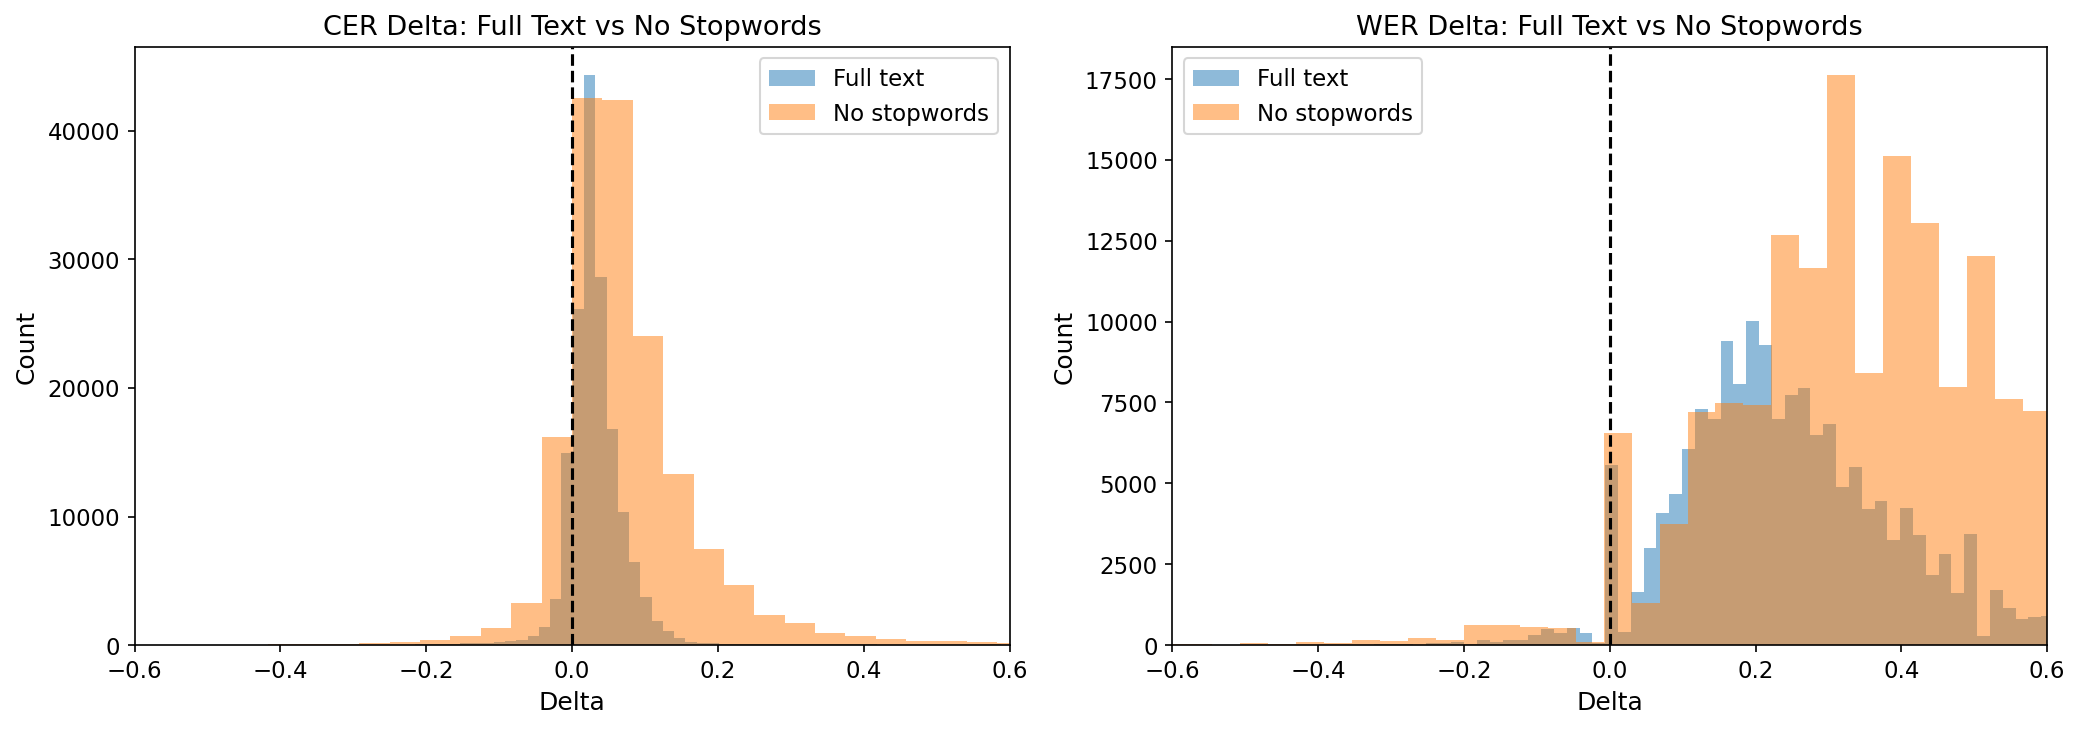

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['cer_delta'].dropna(), bins=100, alpha=0.5, label='Full text')
axes[0].hist(df['cer_delta_nostop'].dropna(), bins=100, alpha=0.5, label='No stopwords')
axes[0].axvline(0, linestyle='--', color='black')
axes[0].set_title('CER Delta: Full Text vs No Stopwords')
axes[0].set_xlabel('Delta')
axes[0].set_ylabel('Count')
axes[0].set_xlim(-0.6, 0.6)
axes[0].legend()

axes[1].hist(df['wer_delta'].dropna(), bins=100, alpha=0.5, label='Full text')
axes[1].hist(df['wer_delta_nostop'].dropna(), bins=100, alpha=0.5, label='No stopwords')
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('WER Delta: Full Text vs No Stopwords')
axes[1].set_xlabel('Delta')
axes[1].set_ylabel('Count')
axes[1].set_xlim(-0.6, 0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. BLEU Score Analysis

In [29]:
smoother = SmoothingFunction().method1

def compute_sentence_bleu(reference: str, hypothesis: str) -> float:
    """Sentence-level BLEU with smoothing."""
    ref = str(reference).lower().split()
    hyp = str(hypothesis).lower().split()
    if not ref or not hyp:
        return 0.0
    try:
        return sentence_bleu([ref], hyp, smoothing_function=smoother)
    except Exception:
        return 0.0

In [30]:
%%time
# Sentence-level BLEU
df['bleu_before'] = df.apply(
    lambda r: compute_sentence_bleu(r['gsent'], r['hsent']), axis=1)
df['bleu_after'] = df.apply(
    lambda r: compute_sentence_bleu(r['gsent'], r['matched_honed_lev']), axis=1)

# For BLEU, higher is better, so positive delta = improvement
df['bleu_delta'] = df['bleu_after'] - df['bleu_before']

print('Sentence BLEU computed.')

Sentence BLEU computed.
CPU times: user 28.6 s, sys: 745 ms, total: 29.3 s
Wall time: 31 s


In [31]:
# Corpus-level BLEU using sacrebleu
refs = [str(g) for g in df['gsent']]

hyps_before = [str(h) for h in df['hsent']]
corpus_bleu_before = sacrebleu.corpus_bleu(hyps_before, [refs])
print(f'Corpus BLEU (before - original OCR): {corpus_bleu_before}')

hyps_after = [str(m) for m in df['matched_honed_lev']]
corpus_bleu_after = sacrebleu.corpus_bleu(hyps_after, [refs])
print(f'Corpus BLEU (after  - re-OCR):       {corpus_bleu_after}')

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Corpus BLEU (before - original OCR): BLEU = 78.56 89.3/81.7/75.2/69.4 (BP = 1.000 ratio = 1.010 hyp_len = 4513196 ref_len = 4469563)


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Corpus BLEU (after  - re-OCR):       BLEU = 77.22 89.3/81.6/75.1/69.2 (BP = 0.984 ratio = 0.985 hyp_len = 4400571 ref_len = 4469563)


In [32]:
print(f'Sentence BLEU (before): mean={df["bleu_before"].mean():.4f}, median={df["bleu_before"].median():.4f}')
print(f'Sentence BLEU (after):  mean={df["bleu_after"].mean():.4f}, median={df["bleu_after"].median():.4f}')
print(f'BLEU delta:             mean={df["bleu_delta"].mean():.4f}, median={df["bleu_delta"].median():.4f}')
print(f'\nSentences improved (delta > 0.01):  {(df["bleu_delta"] > 0.01).sum()}')
print(f'Sentences worsened (delta < -0.01): {(df["bleu_delta"] < -0.01).sum()}')
print(f'Sentences same (|delta| <= 0.01):   {((df["bleu_delta"].abs()) <= 0.01).sum()}')

Sentence BLEU (before): mean=0.7581, median=0.7913
Sentence BLEU (after):  mean=0.4340, median=0.4488
BLEU delta:             mean=-0.3242, median=-0.3169

Sentences improved (delta > 0.01):  5925
Sentences worsened (delta < -0.01): 155250
Sentences same (|delta| <= 0.01):   3640


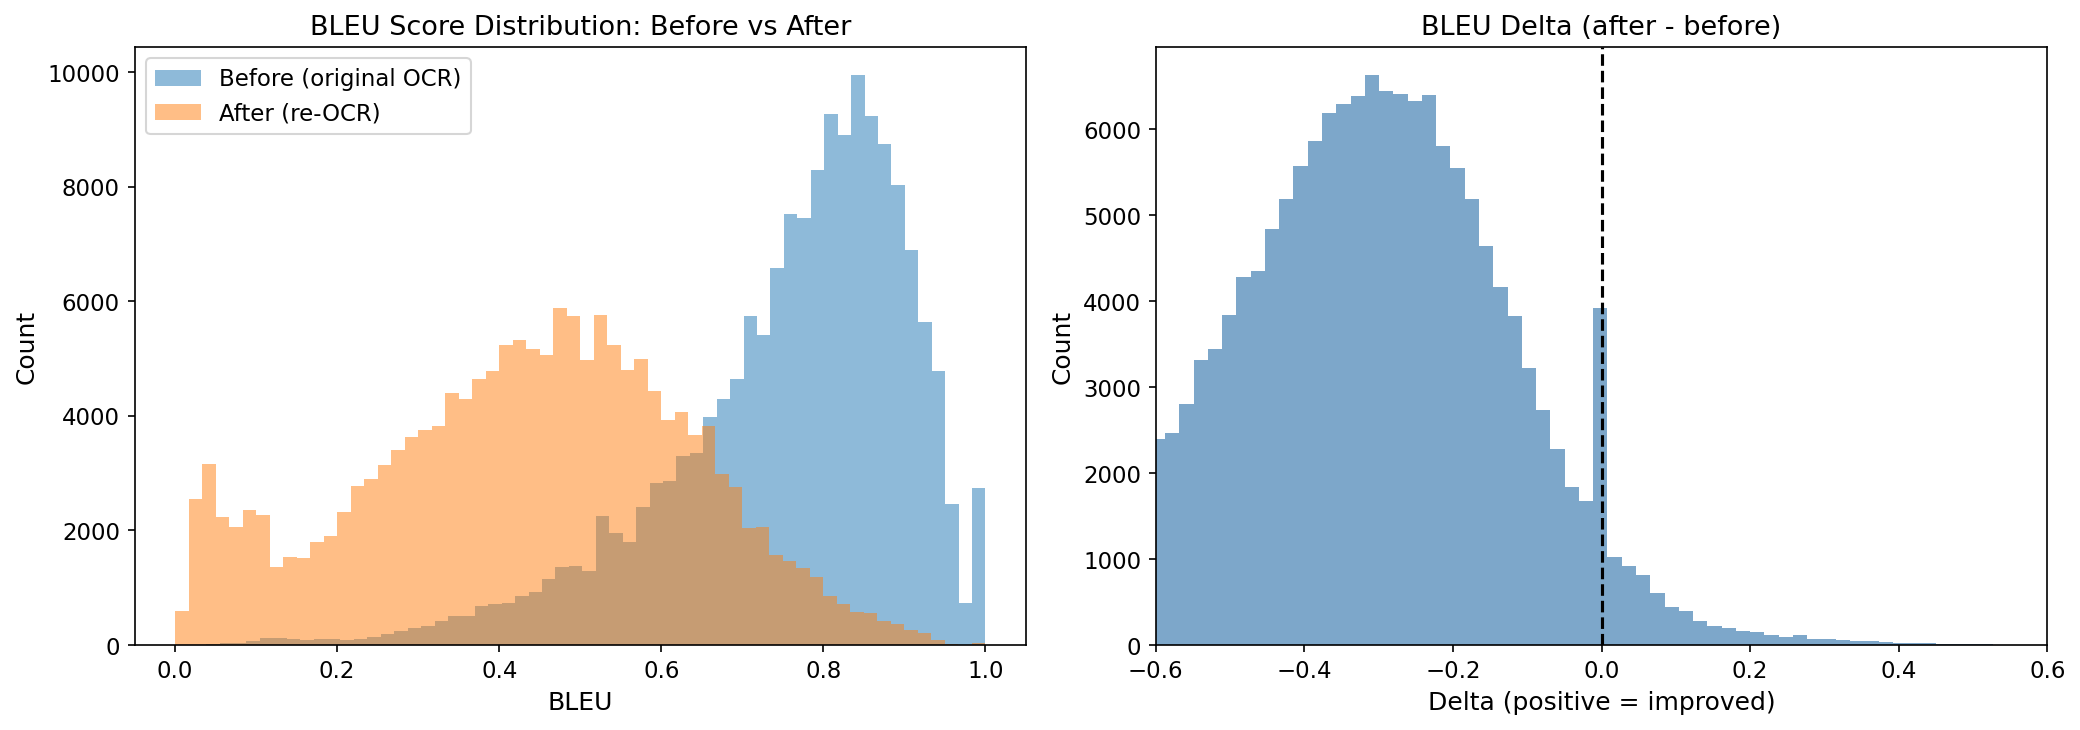

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bleu_before'].dropna(), bins=60, alpha=0.5, label='Before (original OCR)')
axes[0].hist(df['bleu_after'].dropna(), bins=60, alpha=0.5, label='After (re-OCR)')
axes[0].set_title('BLEU Score Distribution: Before vs After')
axes[0].set_xlabel('BLEU')
axes[0].set_ylabel('Count')
axes[0].legend()

s = df['bleu_delta'].dropna()
axes[1].hist(s, bins=100, color='steelblue', alpha=0.7)
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('BLEU Delta (after - before)')
axes[1].set_xlabel('Delta (positive = improved)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(-0.6, 0.6)

plt.tight_layout()
plt.show()

---
## 5. OCRoscope-style 7-gram Analysis

OCRoscope measures OCR quality by the proportion of character 7-grams in a text that do **not** appear in a reference corpus of known-good text. A higher proportion of unrecognized 7-grams indicates worse OCR. We build our reference set from the ground truth (`gsent`) corpus.

In [34]:
%%time
def extract_ngrams(text: str, n: int = 7) -> set:
    """Extract all character n-grams from text."""
    if not isinstance(text, str) or len(text) < n:
        return set()
    text = text.lower()
    return {text[i:i+n] for i in range(len(text) - n + 1)}

# Build reference 7-gram set from all ground truth sentences
ref_ngrams = set()
for gsent in df['gsent'].dropna():
    ref_ngrams.update(extract_ngrams(str(gsent), 7))

print(f'Reference 7-gram set size: {len(ref_ngrams):,}')

Reference 7-gram set size: 1,461,663
CPU times: user 3.09 s, sys: 156 ms, total: 3.24 s
Wall time: 3.43 s


In [35]:
def ocroscope_score(text: str, reference_ngrams: set, n: int = 7) -> float:
    """
    Proportion of character n-grams NOT in reference set.
    0 = all recognized (good), 1 = none recognized (bad).
    """
    if not isinstance(text, str) or len(text) < n:
        return np.nan
    text_lower = text.lower()
    total = len(text_lower) - n + 1
    if total <= 0:
        return np.nan
    unrecognized = sum(
        1 for i in range(total)
        if text_lower[i:i+n] not in reference_ngrams
    )
    return unrecognized / total

In [36]:
%%time
# Compute OCRoscope scores
df['ocroscope_gsent'] = df['gsent'].apply(
    lambda t: ocroscope_score(str(t), ref_ngrams))
df['ocroscope_hsent'] = df['hsent'].apply(
    lambda t: ocroscope_score(str(t), ref_ngrams))
df['ocroscope_matched'] = df['matched_honed_lev'].apply(
    lambda t: ocroscope_score(str(t), ref_ngrams))

# Delta: negative = fewer unrecognized 7-grams = improvement
df['ocroscope_delta'] = df['ocroscope_matched'] - df['ocroscope_hsent']

print('OCRoscope scores computed.')

OCRoscope scores computed.
CPU times: user 11.4 s, sys: 346 ms, total: 11.7 s
Wall time: 12.3 s


In [37]:
%%time
# Heavy-norm BLEU and OCRoscope (apply normalize_heavy to gsent/hsent/matched_honed_lev
# before scoring). Same motivation as cer_*_heavy / wer_*_heavy: removes the punctuation-
# tokenization artifact that makes the light-norm BLEU/OCRoscope register 94–98% of rows
# as worse.

# Heavy-normalized text columns (cached)
_g_heavy = df['gsent'].astype(str).map(normalize_heavy)
_h_heavy = df['hsent'].astype(str).map(normalize_heavy)
_m_heavy = df['matched_honed_lev'].astype(str).map(normalize_heavy)

# --- Heavy OCRoscope ---
ref_ngrams_heavy = set()
for s in _g_heavy:
    ref_ngrams_heavy.update(extract_ngrams(s, 7))
print(f'Heavy 7-gram reference: {len(ref_ngrams_heavy):,}')

df['ocroscope_gsent_heavy']   = _g_heavy.map(lambda s: ocroscope_score(s, ref_ngrams_heavy))
df['ocroscope_hsent_heavy']   = _h_heavy.map(lambda s: ocroscope_score(s, ref_ngrams_heavy))
df['ocroscope_matched_heavy'] = _m_heavy.map(lambda s: ocroscope_score(s, ref_ngrams_heavy))
df['ocroscope_delta_heavy']   = df['ocroscope_matched_heavy'] - df['ocroscope_hsent_heavy']

# --- Heavy BLEU ---
df['bleu_before_heavy'] = [
    compute_sentence_bleu(g, h) for g, h in zip(_g_heavy, _h_heavy)
]
df['bleu_after_heavy']  = [
    compute_sentence_bleu(g, m) for g, m in zip(_g_heavy, _m_heavy)
]
df['bleu_delta_heavy']  = df['bleu_after_heavy'] - df['bleu_before_heavy']

print('\n=== Heavy BLEU ===')
for k, v in improvement_stats(df['bleu_delta_heavy']).items():
    print(f'  {k}: {v}')
print('\n=== Heavy OCRoscope ===')
for k, v in improvement_stats(df['ocroscope_delta_heavy']).items():
    print(f'  {k}: {v}')

Heavy 7-gram reference: 1,335,047

=== Heavy BLEU ===
  mean: -0.006414427512253083
  median: 0.0
  std: 0.15488198993623423
  improved: 45501
  worse: 36582
  same: 82732
  pct_improved: 27.607317295149105
  pct_worse: 22.195795285623273
  pct_same: 50.19688741922762
  total: 164815

=== Heavy OCRoscope ===
  mean: -0.004466808618607719
  median: 0.0
  std: 0.0575416239966037
  improved: 36307
  worse: 37768
  same: 90740
  pct_improved: 22.028941540515124
  pct_worse: 22.915389982707886
  pct_same: 55.055668476776994
  total: 164815
CPU times: user 43 s, sys: 1.26 s, total: 44.3 s
Wall time: 48.4 s


In [38]:
print('=== OCRoscope Scores (proportion of unrecognized 7-grams) ===')
print(f'Ground truth (gsent):    mean={df["ocroscope_gsent"].mean():.4f}  (sanity check: should be ~0)')
print(f'Original OCR (hsent):    mean={df["ocroscope_hsent"].mean():.4f}')
print(f'Re-OCR (matched):        mean={df["ocroscope_matched"].mean():.4f}')
print(f'\n=== OCRoscope Delta (matched - hsent) ===')
ocr_stats = improvement_stats(df['ocroscope_delta'])
for k, v in ocr_stats.items():
    print(f'  {k}: {v}')

=== OCRoscope Scores (proportion of unrecognized 7-grams) ===
Ground truth (gsent):    mean=0.0000  (sanity check: should be ~0)
Original OCR (hsent):    mean=0.0713
Re-OCR (matched):        mean=0.2944

=== OCRoscope Delta (matched - hsent) ===
  mean: 0.2231032580295483
  median: 0.21782178217821782
  std: 0.11239690069110472
  improved: 2846
  worse: 160751
  same: 1218
  pct_improved: 1.726784576646543
  pct_worse: 97.53420501774717
  pct_same: 0.7390104056062858
  total: 164815


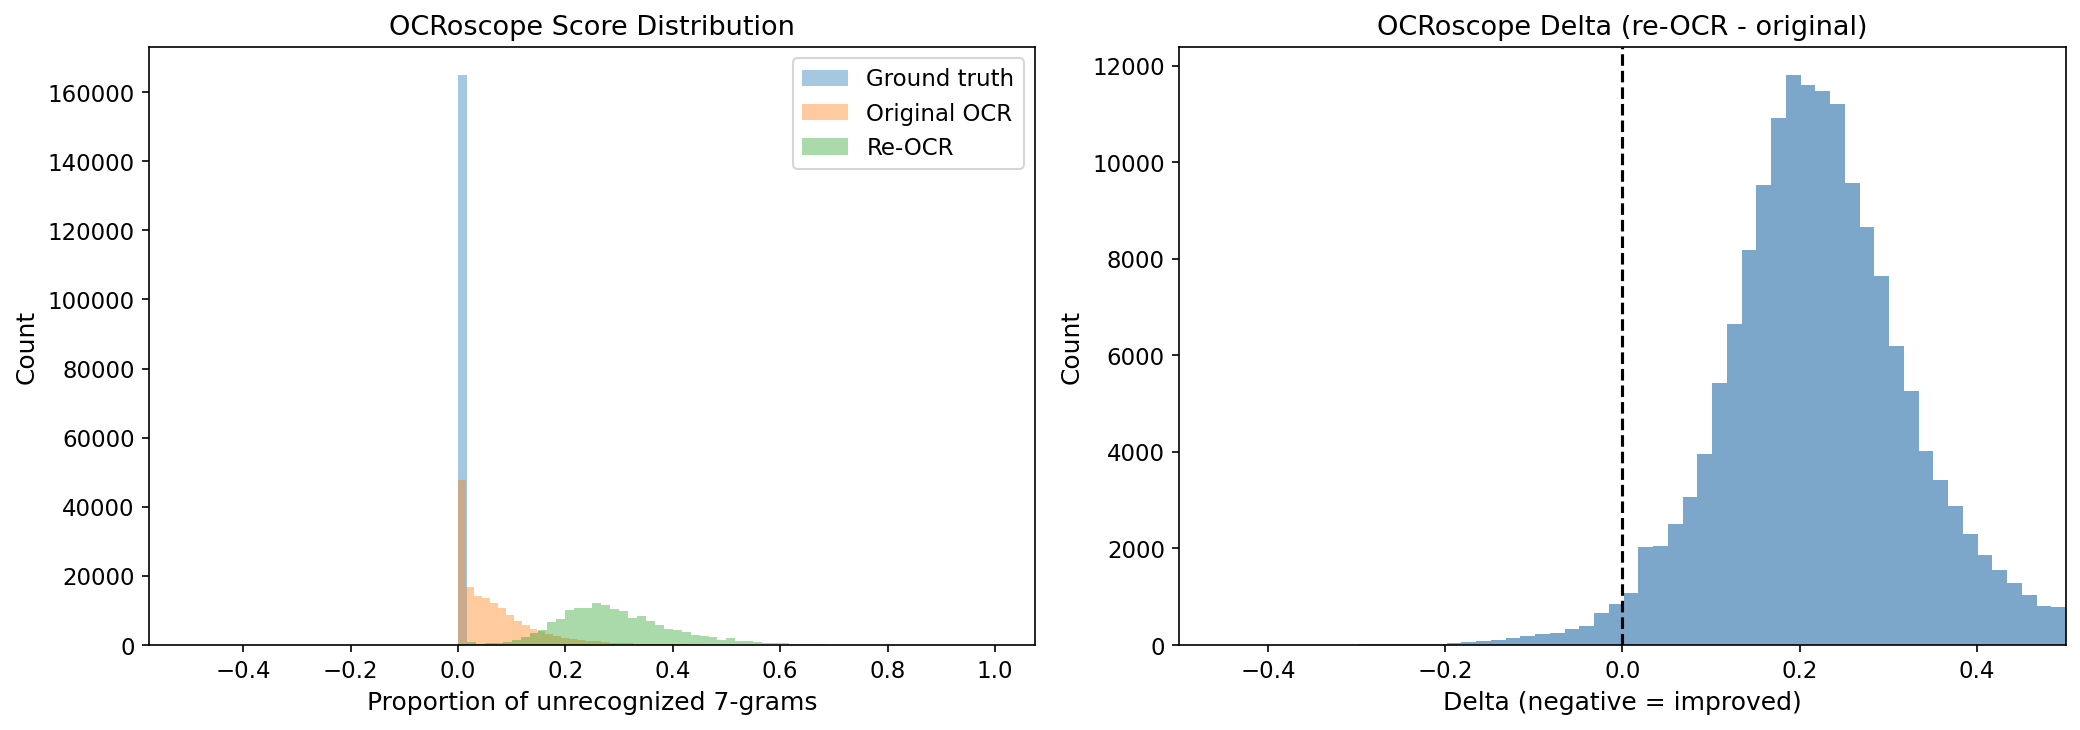

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histograms
axes[0].hist(df['ocroscope_gsent'].dropna(), bins=60, alpha=0.4, label='Ground truth')
axes[0].hist(df['ocroscope_hsent'].dropna(), bins=60, alpha=0.4, label='Original OCR')
axes[0].hist(df['ocroscope_matched'].dropna(), bins=60, alpha=0.4, label='Re-OCR')
axes[0].set_title('OCRoscope Score Distribution')
axes[0].set_xlabel('Proportion of unrecognized 7-grams')
axes[0].set_ylabel('Count')
axes[0].legend()

# Delta histogram
s = df['ocroscope_delta'].dropna()
axes[1].hist(s, bins=100, color='steelblue', alpha=0.7)
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('OCRoscope Delta (re-OCR - original)')
axes[1].set_xlabel('Delta (negative = improved)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

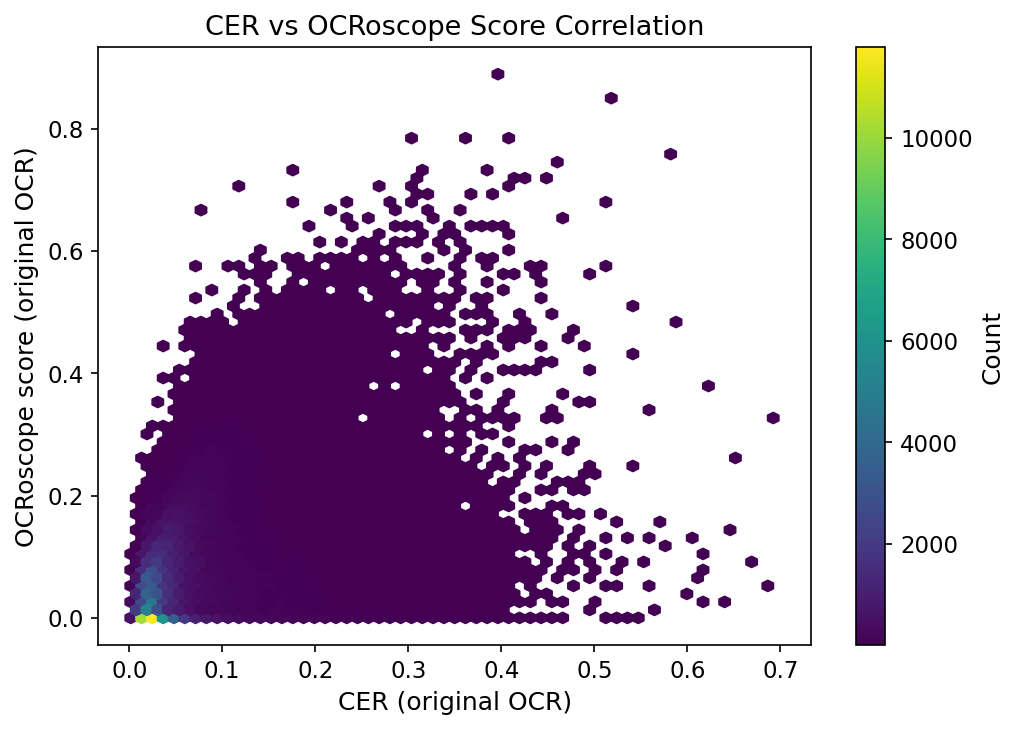

In [40]:
plt.figure(figsize=(7, 5))
plt.hexbin(df['cer_before'], df['ocroscope_hsent'], gridsize=60, cmap='viridis', mincnt=1)
plt.colorbar(label='Count')
plt.xlabel('CER (original OCR)')
plt.ylabel('OCRoscope score (original OCR)')
plt.title('CER vs OCRoscope Score Correlation')
plt.tight_layout()
plt.show()

---
## 6. Residual Failure Tail (heavy-norm)

Under content-focused (heavy) normalization, the apparent WER regression
shrinks from ~25 pp (light norm) to ~1 pp. The rows that still regress are
categorized here by *alignment failure mode*, using the length ratio between
`matched_honed_lev` and `hsent` after heavy normalization:

- `improved` — heavy CER delta < −0.01
- `same` — |heavy CER delta| ≤ 0.01
- `worse_longer_match` — delta > +0.01 *and* matched is >15% longer than hsent (windowing overshoot)
- `worse_shorter_match` — delta > +0.01 *and* matched is >15% shorter (windowing undershoot)
- `worse_rewrite` — delta > +0.01 *and* similar length (genuine content difference after punctuation stripped)

The two window-failure categories (`longer_match` + `shorter_match`) are the
most actionable — they point at the aligner's window-expansion heuristic in
`sent_match_lev_algo_improved.py`.

In [41]:
# Per-row alignment-failure category, based on heavy-norm CER delta + length ratio.
# Uses normalize_heavy(hsent) vs normalize_heavy(matched_honed_lev) for length measurement.

_TOL_CER = 0.01
_LEN_HI = 1.15
_LEN_LO = 0.85

_h_heavy = df['hsent'].astype(str).map(normalize_heavy)
_m_heavy = df['matched_honed_lev'].astype(str).map(normalize_heavy)
_h_len = _h_heavy.str.len().replace(0, np.nan)
_m_len = _m_heavy.str.len()
df['heavy_len_ratio'] = (_m_len / _h_len).round(3)


def _classify_outcome(cer_delta, len_ratio):
    if pd.isna(cer_delta):
        return 'na'
    if cer_delta < -_TOL_CER:
        return 'improved'
    if cer_delta <= _TOL_CER:
        return 'same'
    if pd.isna(len_ratio):
        return 'worse_unknown'
    if len_ratio > _LEN_HI:
        return 'worse_longer_match'
    if len_ratio < _LEN_LO:
        return 'worse_shorter_match'
    return 'worse_rewrite'


df['outcome_cer_heavy'] = [
    _classify_outcome(d, r) for d, r in zip(df['cer_delta_heavy'], df['heavy_len_ratio'])
]

outcome_counts = df['outcome_cer_heavy'].value_counts()
outcome_pct = (outcome_counts / len(df) * 100).round(2)
print('Row-level outcome (CER heavy):')
for cat, n in outcome_counts.items():
    print(f'  {cat:22s}  n={n:>7d}  ({outcome_pct[cat]:5.2f}%)')

print('\nPer-category delta summary (heavy CER):')
display(df.groupby('outcome_cer_heavy')['cer_delta_heavy']
          .agg(['count', 'median', 'mean']).round(4))

Row-level outcome (CER heavy):
  same                    n= 106886  (64.85%)
  improved                n=  30661  (18.60%)
  worse_rewrite           n=  25793  (15.65%)
  worse_shorter_match     n=    760  ( 0.46%)
  worse_longer_match      n=    715  ( 0.43%)

Per-category delta summary (heavy CER):


,count,median,mean
outcome_cer_heavy,,,
improved,30661,-0.0244,-0.0356
same,106886,0.0000,0.0006
worse_longer_match,715,0.4937,0.4300
worse_rewrite,25793,0.0182,0.0334
worse_shorter_match,760,0.3024,0.3142


---
## 6. Consolidated Summary

In [42]:
# Master summary table — HEAVY-norm CER/WER/BLEU/OCRoscope are the primary results;
# light/no-stopword/etc. remain as sensitivity analyses.
#
# For CER/WER/OCRoscope, lower is better → negative delta = improvement.
# For BLEU, higher is better → positive delta = improvement.

summary_rows = []
for label, before_col, after_col, delta_col, lower_better in [
    ('CER (heavy, PRIMARY)',           'cer_before_heavy',       'cer_after_heavy',       'cer_delta_heavy',       True),
    ('WER (heavy, PRIMARY)',           'wer_before_heavy',       'wer_after_heavy',       'wer_delta_heavy',       True),
    ('BLEU (heavy, PRIMARY)',          'bleu_before_heavy',      'bleu_after_heavy',      'bleu_delta_heavy',      False),
    ('OCRoscope 7-gram (heavy, PRIMARY)','ocroscope_hsent_heavy','ocroscope_matched_heavy','ocroscope_delta_heavy', True),
    ('CER (light)',                    'cer_before',             'cer_after',             'cer_delta',             True),
    ('CER (NFKC+lower)',               'cer_before_norm',        'cer_after_norm',        'cer_delta_norm',        True),
    ('CER (no stop)',                  'cer_before_nostop',      'cer_after_nostop',      'cer_delta_nostop',      True),
    ('WER (light)',                    'wer_before',             'wer_after',             'wer_delta',             True),
    ('WER (no stop)',                  'wer_before_nostop',      'wer_after_nostop',      'wer_delta_nostop',      True),
    ('BLEU (light)',                   'bleu_before',            'bleu_after',            'bleu_delta',            False),
    ('OCRoscope 7-gram (light)',       'ocroscope_hsent',        'ocroscope_matched',     'ocroscope_delta',       True),
]:
    st = improvement_stats(df[delta_col])
    summary_rows.append({
        'Metric': label,
        'Before (mean)': df[before_col].mean(),
        'After (mean)': df[after_col].mean(),
        'Delta (mean)': df[delta_col].mean(),
        '% Improved': st['pct_improved'] if lower_better else st['pct_worse'],
        '% Worsened': st['pct_worse'] if lower_better else st['pct_improved'],
        '% Same': st['pct_same'],
    })

summary_table = pd.DataFrame(summary_rows).set_index('Metric')
display(summary_table.round(4))

,Before (mean),After (mean),Delta (mean),% Improved,% Worsened,% Same
Metric,,,,,,
"CER (heavy, PRIMARY)",0.0423,0.0446,0.0023,18.6033,16.5446,64.8521
"WER (heavy, PRIMARY)",0.0998,0.1119,0.0121,20.2057,28.0800,51.7143
"BLEU (heavy, PRIMARY)",0.8241,0.8177,-0.0064,22.1958,27.6073,50.1969
"OCRoscope 7-gram (heavy, PRIMARY)",0.0540,0.0496,-0.0045,22.0289,22.9154,55.0557
CER (light),0.0572,0.0927,0.0355,5.8320,81.0011,13.1669
CER (NFKC+lower),0.0549,0.0904,0.0355,5.7865,80.8646,13.3489
CER (no stop),0.0947,0.1714,0.0767,8.0454,85.0086,6.9460
WER (light),0.1397,0.3876,0.2479,1.9531,94.6716,3.3753
WER (no stop),0.2139,0.5658,0.3519,2.1096,93.9186,3.9717


In [43]:
# Per-domain breakdown
domain_summary = []
for domain in sorted(df['domain'].unique()):
    mask = df['domain'] == domain
    n = mask.sum()
    domain_summary.append({
        'Domain': domain,
        'N': n,
        'CER delta (mean)': df.loc[mask, 'cer_delta'].mean(),
        'WER delta (mean)': df.loc[mask, 'wer_delta'].mean(),
        'BLEU delta (mean)': df.loc[mask, 'bleu_delta'].mean(),
        'OCRoscope delta (mean)': df.loc[mask, 'ocroscope_delta'].mean(),
    })

domain_df = pd.DataFrame(domain_summary).set_index('Domain')
display(domain_df.round(4))

,N,CER delta (mean),WER delta (mean),BLEU delta (mean),OCRoscope delta (mean)
Domain,,,,,
Agriculture,3204,0.0304,0.2244,-0.3265,0.2314
Fiction,155153,0.0361,0.2508,-0.3271,0.2244
Social_Science,4380,0.0260,0.2004,-0.2636,0.1951
World_War_History,2078,0.0189,0.1675,-0.2248,0.1721


In [44]:
# Per csv_source breakdown (highpairs vs lowpairs)
source_summary = []
for src in sorted(df['csv_source'].unique()):
    mask = df['csv_source'] == src
    n = mask.sum()
    source_summary.append({
        'Source': src,
        'N': n,
        'CER before (mean)': df.loc[mask, 'cer_before'].mean(),
        'CER after (mean)': df.loc[mask, 'cer_after'].mean(),
        'CER delta (mean)': df.loc[mask, 'cer_delta'].mean(),
        'WER delta (mean)': df.loc[mask, 'wer_delta'].mean(),
        'BLEU delta (mean)': df.loc[mask, 'bleu_delta'].mean(),
    })

source_df = pd.DataFrame(source_summary).set_index('Source')
display(source_df.round(4))

,N,CER before (mean),CER after (mean),CER delta (mean),WER delta (mean),BLEU delta (mean)
Source,,,,,,
highpairs,104892,0.0607,0.0927,0.0320,0.2349,-0.3002
lowpairs,59923,0.0510,0.0927,0.0417,0.2707,-0.3661


In [45]:
import os
os.makedirs('_cache', exist_ok=True)

output_cols = [
    'idx', 'csv_source', 'domain', 'gid', 'hid', 'pubdate', 'cidx', 'sidx',
    # primary (heavy norm)
    'cer_before_heavy', 'cer_after_heavy', 'cer_delta_heavy',
    'wer_before_heavy', 'wer_after_heavy', 'wer_delta_heavy',
    'bleu_before_heavy', 'bleu_after_heavy', 'bleu_delta_heavy',
    'ocroscope_hsent_heavy', 'ocroscope_matched_heavy', 'ocroscope_delta_heavy',
    # sensitivity (light norm — whitespace-collapsed, hyphens stripped)
    'cer_before', 'cer_after', 'cer_delta',
    'cer_before_norm', 'cer_after_norm', 'cer_delta_norm',
    'wer_before', 'wer_after', 'wer_delta',
    # no-stopword sensitivity
    'cer_before_nostop', 'cer_after_nostop', 'cer_delta_nostop',
    'wer_before_nostop', 'wer_after_nostop', 'wer_delta_nostop',
    # other (light) metrics
    'bleu_before', 'bleu_after', 'bleu_delta',
    'ocroscope_hsent', 'ocroscope_matched', 'ocroscope_delta',
    # failure diagnostic
    'heavy_len_ratio', 'outcome_cer_heavy',
]
df[output_cols].to_csv('_cache/final_analysis_results.csv', index=False)
print(f'Saved {len(df)} rows to _cache/final_analysis_results.csv')

Saved 164815 rows to _cache/final_analysis_results.csv
